# Final Project Model Submission

##### Author: Tommy Flanagan
##### School: Lasell University
##### Date: 4.14.2026



## Summary:

#### The goal of this project is to predict hit probability based on a multitude of input features which have been acquired through the pybaseball library in Python. This contains statcast data from the Statcast Era in MLB (2015-present). 

## NOTE!

#### It is best to run the file from top to bottom once and not go back and run previous cells. For example, creating the hit column (you will see below) can only be created once and it will fail if you try to run the cell again. Running from top to bottom with doing each cell once ensures everything works!

In [1]:
# Python 3.11.1 used

import pybaseball
from pybaseball import statcast
from pybaseball import cache
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import time

cache.enable()

print('Pybaseball imported successfully!')
print('RandomForestRegressor imported successfully!')
print('Tensorflow imported successfully!')

Pybaseball imported successfully!
RandomForestRegressor imported successfully!
Tensorflow imported successfully!


In [2]:
# Versions of each library

print(f'Pybaseball Version: {pybaseball.__version__}')
print(f'Pandas Version: {pd.__version__}')
print(f'NumPy Version: {np.__version__}')
print(f'Matplotlib Version: {matplotlib.__version__}')
print(f'Scikit Version: {sklearn.__version__}')
print(f'Tensorflow Version: {tf.__version__}')

Pybaseball Version: 2.2.7
Pandas Version: 3.0.1
NumPy Version: 2.4.2
Matplotlib Version: 3.10.8
Scikit Version: 1.8.0
Tensorflow Version: 2.20.0


In [3]:
# Start and end dates for 2025 MLB regular season
data = statcast(start_dt="2025-03-18", end_dt="2025-09-28")

This is a large query, it may take a moment to complete


100%|██████████| 195/195 [00:24<00:00,  7.84it/s]


In [4]:
print('Shape of Dataset:')
print(data.shape)

print('Variables:')
for col in data.columns:
    print(col)

Shape of Dataset:
(742080, 118)
Variables:
pitch_type
game_date
release_speed
release_pos_x
release_pos_z
player_name
batter
pitcher
events
description
spin_dir
spin_rate_deprecated
break_angle_deprecated
break_length_deprecated
zone
des
game_type
stand
p_throws
home_team
away_team
type
hit_location
bb_type
balls
strikes
game_year
pfx_x
pfx_z
plate_x
plate_z
on_3b
on_2b
on_1b
outs_when_up
inning
inning_topbot
hc_x
hc_y
tfs_deprecated
tfs_zulu_deprecated
umpire
sv_id
vx0
vy0
vz0
ax
ay
az
sz_top
sz_bot
hit_distance_sc
launch_speed
launch_angle
effective_speed
release_spin_rate
release_extension
game_pk
fielder_2
fielder_3
fielder_4
fielder_5
fielder_6
fielder_7
fielder_8
fielder_9
release_pos_y
estimated_ba_using_speedangle
estimated_woba_using_speedangle
woba_value
woba_denom
babip_value
iso_value
launch_speed_angle
at_bat_number
pitch_number
pitch_name
home_score
away_score
bat_score
fld_score
post_away_score
post_home_score
post_bat_score
post_fld_score
if_fielding_alignment
of_fieldi

In [5]:
# Null values per category
data.isnull().sum()

pitch_type                                   12323
game_date                                        0
release_speed                                12264
release_pos_x                                12267
release_pos_z                                12267
                                             ...  
attack_angle                                410167
attack_direction                            410167
swing_path_tilt                             410170
intercept_ball_minus_batter_pos_x_inches    410658
intercept_ball_minus_batter_pos_y_inches    410658
Length: 118, dtype: int64

In [6]:
# How many batted ball events there are per category
print(data['events'].value_counts())

events
field_out                    77175
strikeout                    42299
single                       27230
walk                         15512
double                        8086
home_run                      5867
force_out                     3510
grounded_into_double_play     3274
hit_by_pitch                  2015
sac_fly                       1343
field_error                   1065
triple                         665
sac_bunt                       569
intent_walk                    559
fielders_choice                397
double_play                    393
fielders_choice_out            337
truncated_pa                   333
strikeout_double_play          129
catcher_interf                  90
sac_fly_double_play             18
triple_play                      3
Name: count, dtype: int64


In [7]:
# Widdling down our event outcomes
# ONLY keeping events where the ball was put in play
     # Events such as walks and catchers interference are not outcomes that come from putting the ball in play
     # Even though a sac bunt is putting the ball in play, the goal is not to get on base, so that one was also omitted 

events_to_keep = [
    'field_out',
    'force_out',
    'single',
    'double',
    'triple',
    'home_run',
    'field_error',
    'grounded_into_double_play',
    'sac_fly',
    'fielders_choice',
    'double_play',
    'fielders_choice_out',
    'sac_fly_double_play',
    'triple_play'
]

filtered_data = data[data['events'].isin(events_to_keep)]

print(filtered_data['events'].value_counts())
filtered_data.isnull().sum()

events
field_out                    77175
single                       27230
double                        8086
home_run                      5867
force_out                     3510
grounded_into_double_play     3274
sac_fly                       1343
field_error                   1065
triple                         665
fielders_choice                397
double_play                    393
fielders_choice_out            337
sac_fly_double_play             18
triple_play                      3
Name: count, dtype: int64


pitch_type                                   1689
game_date                                       0
release_speed                                1689
release_pos_x                                1689
release_pos_z                                1689
                                            ...  
attack_angle                                10432
attack_direction                            10432
swing_path_tilt                             10433
intercept_ball_minus_batter_pos_x_inches    10507
intercept_ball_minus_batter_pos_y_inches    10507
Length: 118, dtype: int64

In [8]:
# The 12 features that I picked for my random forest and neural network 
# I decided not to engineer any features based on these 12
     # REASONS:
          # 1. Features don't hold enough relevance toward each other for some numerical output to hold any value
                  # - There is no total_bath = full_bath + .5*half_bath equivalent here. Each feature has its own distinction and engineering a feature would 
                  # not hold any necessary substance
          # 2. The 12 features don't need added context 
                  # Based on the 12 selected, there is nothing else that those outputs can add to potential accuracy of models
          # 3. For this section of the project, more features would just decrease the sample size that has already shrunk

# Depending on the accuracy of the first random forest and neural network, I may add engineered features for the imputation section 
# Also, while I did not "engineer" any features, using pd.get_dummmies for my categorical variables does take the total variables up to 29

features = [
    "launch_speed",
    "launch_angle",
    "pitch_type",
    "hit_location",
    "bat_speed",
    "swing_length",
    "swing_path_tilt",
    "if_fielding_alignment",
    "of_fielding_alignment",
    'hit_distance_sc',
    'release_speed',
    ]

# WARNING!!! Sometimes the kernel will randomly crash because of the line below. The syntax is not wrong, the kernel just gets jumbled when I jump around.
# I fix this by saving the file, then closing it with the 'x' in teh top right and reopening the file and run it from the beginning.
     # Once the kernel is reset, this works everytime.

# Or, you can comment out just this line (so it does not try to create the hit column again) and that will work too
filtered_data["hit"] = filtered_data["events"].isin(["single","double","triple","home_run"]).astype(int)

ovr_data_original = filtered_data
print(ovr_data_original.shape)

filtered_data = filtered_data.dropna(subset=features)

filtered_data = filtered_data[features + ["hit"]]

filtered_data_encoded = pd.get_dummies(filtered_data, columns=['pitch_type', 'if_fielding_alignment', 'of_fielding_alignment'])

print('Total Observations Updated (non encoded shape):')
print(filtered_data.shape)

print('Total Observations Updated (updated shape using pd.get_dummies)')
print(filtered_data_encoded.shape)


(129363, 119)
Total Observations Updated (non encoded shape):
(112693, 12)
Total Observations Updated (updated shape using pd.get_dummies)
(112693, 30)


In [9]:
# Updating baseline features to use in random forest

baseline_features = [
    "launch_speed",
    "launch_angle",
    "hit_location",
    "bat_speed",
    "swing_length",
    "swing_path_tilt",
    "hit_distance_sc",
    "release_speed",
    "pitch_type_CH",
    "pitch_type_CS",
    "pitch_type_CU",
    "pitch_type_EP",
    "pitch_type_FA",
    "pitch_type_FC",
    "pitch_type_FF",
    "pitch_type_FO",
    "pitch_type_FS",
    "pitch_type_KC",
    "pitch_type_KN",
    "pitch_type_SI",
    "pitch_type_SL",
    "pitch_type_ST",
    "pitch_type_SV",
    "if_fielding_alignment_Infield shade",
    "if_fielding_alignment_Standard",
    "if_fielding_alignment_Strategic",
    "of_fielding_alignment_Standard",
    "of_fielding_alignment_Strategic",
]

print("Features updated successfully!")

Features updated successfully!


In [10]:
# Creating my X and y

X_baseline = filtered_data_encoded[baseline_features]
y = filtered_data_encoded['hit']

print(f'Baseline features selected: {len(baseline_features)}')
print(f'Target variable shape: {y.shape}')

Baseline features selected: 28
Target variable shape: (112693,)


In [11]:
# Creating train and test splits 
start_time = time.time()

X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=.2, random_state=42
)

baseline_rf = RandomForestRegressor(n_estimators=100, random_state=42)
baseline_rf.fit(X_train, y_train)

baseline_time = time.time() - start_time

baseline_predictions = baseline_rf.predict(X_test)

baseline_r2 = r2_score(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))

print(f'Baseline RF R^2 Score: {baseline_r2:,.4f}')
print(f'Baseline RF RMSE: {baseline_rmse:,.4f}')
print(f'Baseline RF Training Time: {baseline_time:,.2f}')

Baseline RF R^2 Score: 0.6680
Baseline RF RMSE: 0.2596
Baseline RF Training Time: 40.92


Text(0.5, 1.0, 'Feature Importances for Hit Probability Prediction')

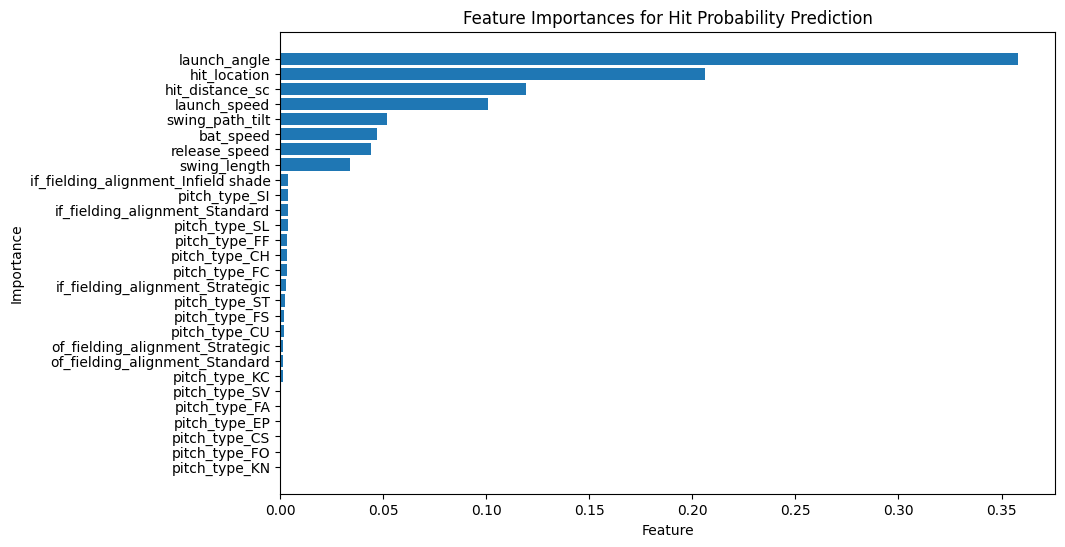

In [12]:
# Collecting feature importances

feature_importances = pd.DataFrame({
    'feature': baseline_features,
    'importance': baseline_rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances for Hit Probability Prediction')

## Baseline RF Summary

##### I originally had babip_value (batting average for ball in play value) as one of my features, but I will show you below why I took it out and made my baseline rf 11 features instead of 12. 

##### Based on those 11 features, I predicted hit probability with ~67% accuracy. This does not reflect the number I was chasing, but 2/3 accuracy for my first model is something I will take. Launch angle was my prediction for the top spot and that has that by a large margin, but it is interesting to see what falls in behind it. One thing I am surprised to see is how low the infield and outfield adjustments are compared to other features. Teams have a higher stress on alignment with these things even after the "shift" ban. However, while these numbers are lower, the infield alignment also has the highest placement for what an opposing team can control. Overall, I am happy with my model.

# Below is another random forest with just babip_value added

In [13]:
second_features = [
    "launch_speed",
    "launch_angle",
    "pitch_type",
    "hit_location",
    "bat_speed",
    "babip_value",
    "swing_length",
    "swing_path_tilt",
    "if_fielding_alignment",
    "of_fielding_alignment",
    'hit_distance_sc',
    'release_speed',
    ]

second_filtered = data[data['events'].isin(events_to_keep)]

second_filtered["hit"] = second_filtered["events"].isin(["single","double","triple","home_run"]).astype(int)

second_filtered = second_filtered.dropna(subset=second_features)

second_filtered = second_filtered[second_features + ["hit"]]

second_filtered_encoded = pd.get_dummies(second_filtered, columns=['pitch_type', 'if_fielding_alignment', 'of_fielding_alignment'])

In [14]:
second_rf_features = [
    "launch_speed",
    "launch_angle",
    "hit_location",
    "bat_speed",
    "swing_length",
    "swing_path_tilt",
    "hit_distance_sc",
    "release_speed",
    "babip_value",  ## Literally the ONLY thing I've added
    "pitch_type_CH",
    "pitch_type_CS",
    "pitch_type_CU",
    "pitch_type_EP",
    "pitch_type_FA",
    "pitch_type_FC",
    "pitch_type_FF",
    "pitch_type_FO",
    "pitch_type_FS",
    "pitch_type_KC",
    "pitch_type_KN",
    "pitch_type_SI",
    "pitch_type_SL",
    "pitch_type_ST",
    "pitch_type_SV",
    "if_fielding_alignment_Infield shade",
    "if_fielding_alignment_Standard",
    "if_fielding_alignment_Strategic",
    "of_fielding_alignment_Standard",
    "of_fielding_alignment_Strategic",
]

print("Features updated successfully!")

Features updated successfully!


In [15]:
X_second = second_filtered_encoded[second_rf_features]
y = second_filtered_encoded['hit']

print(f'Baseline features selected: {len(second_rf_features)}')
print(f'Target variable shape: {y.shape}')

Baseline features selected: 29
Target variable shape: (112693,)


In [16]:
start_time = time.time()

X_train, X_test, y_train, y_test = train_test_split(
    X_second, y, test_size=.2, random_state=42
)

second_rf = RandomForestRegressor(n_estimators=100, random_state=42)
second_rf.fit(X_train, y_train)

second_rf_time = time.time() - start_time

second_predictions = second_rf.predict(X_test)

second_r2 = r2_score(y_test, second_predictions)
second_rmse = np.sqrt(mean_squared_error(y_test, second_predictions))

print(f'Second RF R^2 Score: {second_r2:,.4f}')
print(f'Second RF RMSE: {second_rmse:,.4f}')
print(f'Second RF Training Time: {second_rf_time:.2f}')

Second RF R^2 Score: 0.9996
Second RF RMSE: 0.0094
Second RF Training Time: 7.79


## NOTE!

#### This was my original rf model and I was supremley happy with it. However, the graph below will show you why I scrapped it and went with my baseline_rf instead of the outline in the second_rf.

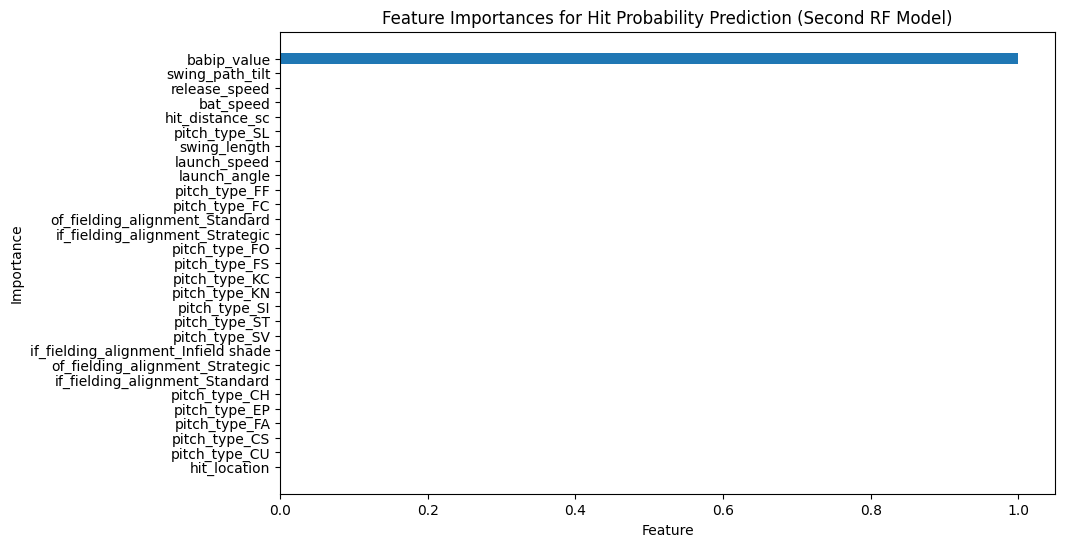

In [17]:
feature_importances_2 = pd.DataFrame({
    'feature': second_rf_features,
    'importance': second_rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feature_importances_2['feature'], feature_importances_2['importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances for Hit Probability Prediction (Second RF Model)')
plt.show()

## Second RF Summary

##### As you can see, the babip_value completley overtakes the model with almost perfect accuracy. This does make sense because it is a value assigned to a ball in play with its corresponding potential batting average. This correlates directly with the hit probability scope I am trying to accomplish. I could have just kept this, but even though it made the model more accurate, it just rendered the other variables essentially useless. 

##### Next up is the neural network part of this assignment!

In [18]:
# Starting the neural network process

X = filtered_data_encoded.reindex(columns=baseline_features)
y = filtered_data_encoded["hit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = .2,
    random_state=42, 
    stratify = y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = np.array(X_train_scaled, dtype=np.float32)
X_test_scaled = np.array(X_test_scaled, dtype=np.float32)
y_train = np.array(y_train, dtype=np.int32)
y_test = np.array(y_test, dtype=np.int32)

print("Scaling for NN complete!")

Scaling for NN complete!


In [19]:
# Creating and compiling first neural network with subsequent summary

first_nn = keras.Sequential([
    layers.Input(shape=(28,)),
    layers.Dense(64, activation='relu', input_shape = (28,)),
    layers.Dense(2, activation='softmax')
])

first_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

first_nn.summary()

c:\Users\flana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,986 (7.76 KB)

 Trainable params: 1,986 (7.76 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
start_time = time.time()

first_nn_history = first_nn.fit(
    X_train_scaled,
    y_train,
    epochs = 20,
    batch_size = 100, 
    validation_split = .2,
    verbose = 1
)

first_nn_time = time.time() - start_time

first_nn_test_loss, first_nn_test_accuracy = first_nn.evaluate(
    X_test_scaled, y_test, verbose = 0
)

print(f'Test Accuracy: {first_nn_test_accuracy:.4f}')
print(f'Testting Loss: {first_nn_test_loss:.4f}')
print(f'First NN Training time: {first_nn_time:.2f}')


Epoch 1/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8293 - loss: 0.4163 - val_accuracy: 0.8807 - val_loss: 0.3382
Epoch 2/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8819 - loss: 0.3231 - val_accuracy: 0.8854 - val_loss: 0.3153
Epoch 3/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8874 - loss: 0.3037 - val_accuracy: 0.8871 - val_loss: 0.3004
Epoch 4/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8928 - loss: 0.2915 - val_accuracy: 0.8887 - val_loss: 0.2932
Epoch 5/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8964 - loss: 0.2837 - val_accuracy: 0.8951 - val_loss: 0.2830
Epoch 6/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8976 - loss: 0.2774 - val_accuracy: 0.8982 - val_loss: 0.2821
Epoch 7/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8993 - loss: 0.2735 - val_accuracy: 0.9008 - val_loss: 0.2724
Epoch 8/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9007 - loss: 0.2695 - val_accuracy: 0.

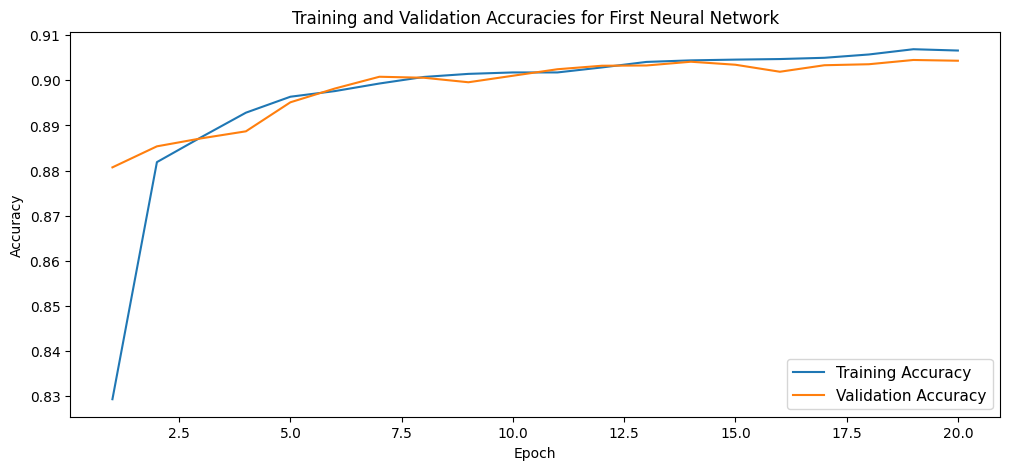

In [21]:
# Visualization for First NN

train_accuracy = first_nn_history.history['accuracy']
val_accuracy = first_nn_history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(12,5))

plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')

plt.title("Training and Validation Accuracies for First Neural Network")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(loc='lower right', fontsize=11)


## NN Evaluation

##### The neural network performed much better than the random forest with its test accuracy. I've ran it three times and each one comes at ~90% accuracy. I only did one hidden layer because I had 28 features as opposed to previous assignments when I had north of 500. The chances of overfitting are higher when there are more hidden layers because the neural network has a higher chance of memorization with training data. Moving forward, if I were to do this project on my own, I would lean toward using a neural network instead of random forest because of this accuracy disparity.

# Random Forest with Imputations

##### Now I am going to go back into the random forest and neural network model with some imputation methods so the sample size is not shot down as much. For the neural network, I am not as concerned with the output (even though I will still do it) because the ~90% accuracy is terrific. I am more interested to see if it can improve the 67% accuracy from the random forest model.

In [22]:
# Features below as a reminder

features = [
    "launch_speed",
    "launch_angle",
    "pitch_type",
    "hit_location",
    "bat_speed",
    "swing_length",
    "swing_path_tilt",
    "if_fielding_alignment",
    "of_fielding_alignment",
    'hit_distance_sc',
    'release_speed',
    ]

# Splitting up features for numeric and categorical

numeric_features = [
    "launch_speed",
    "launch_angle",
    "bat_speed",
    "swing_length",
    "swing_path_tilt",
    'hit_distance_sc',
    'release_speed',
    'hit_location'
]

categorical_features = [
    "pitch_type",
    "if_fielding_alignment",
    "of_fielding_alignment",
]

for col in numeric_features:
    ovr_data_original[col] = ovr_data_original[col].fillna(ovr_data_original[col].median())

for col in categorical_features:
    ovr_data_original[col] = ovr_data_original[col].fillna(ovr_data_original[col].mode()[0])

filtered_data_third_rf = ovr_data_original[features + ["hit"]]

print(filtered_data_third_rf.shape)

# Shape should come out to ~129,000. If it drops to 112,000 for whatever reason, restart the kernel and go through the file again
     # It will return to 129,000 then

(129363, 12)


In [23]:
third_rf_encoded = pd.get_dummies(filtered_data_third_rf, columns=['pitch_type', 'if_fielding_alignment', 'of_fielding_alignment'])
print(third_rf_encoded.shape)

(129363, 30)


In [24]:
third_rf_features = [
    "launch_speed",
    "launch_angle",
    "hit_location",
    "bat_speed",
    "swing_length",
    "swing_path_tilt",
    "hit_distance_sc",
    "release_speed",
    "pitch_type_CH",
    "pitch_type_CS",
    "pitch_type_CU",
    "pitch_type_EP",
    "pitch_type_FA",
    "pitch_type_FC",
    "pitch_type_FF",
    "pitch_type_FO",
    "pitch_type_FS",
    "pitch_type_KC",
    "pitch_type_KN",
    "pitch_type_SI",
    "pitch_type_SL",
    "pitch_type_ST",
    "pitch_type_SV",
    "if_fielding_alignment_Infield shade",
    "if_fielding_alignment_Standard",
    "if_fielding_alignment_Strategic",
    "of_fielding_alignment_Standard",
    "of_fielding_alignment_Strategic",
]

print('Features Updated Successfully!')

Features Updated Successfully!


In [25]:
X_third = third_rf_encoded[third_rf_features]
y = third_rf_encoded['hit']

print(f'Baseline features selected: {len(third_rf_features)}')
print(f'Target variable shape: {y.shape}')

Baseline features selected: 28
Target variable shape: (129363,)


In [26]:
start_time = time.time()

X_train, X_test, y_train, y_test = train_test_split(
    X_third, y, test_size=.2, random_state=42
)

third_rf = RandomForestRegressor(n_estimators=100, random_state=42)
third_rf.fit(X_train, y_train)

third_rf_time = time.time() - start_time

third_rf_predictions = third_rf.predict(X_test)

third_rf_r2 = r2_score(y_test, third_rf_predictions)
third_rf_rmse = np.sqrt(mean_squared_error(y_test, third_rf_predictions))

print(f'Third RF R^2 Score: {third_rf_r2:,.4f}')
print(f'Third RF RMSE: {third_rf_rmse:,.4f}')
print(f'Third RF Training Time: {third_rf_time:,.2f}')

Third RF R^2 Score: 0.6637
Third RF RMSE: 0.2715
Third RF Training Time: 44.14


Text(0.5, 1.0, 'Feature Importances for Hit Probability Prediction')

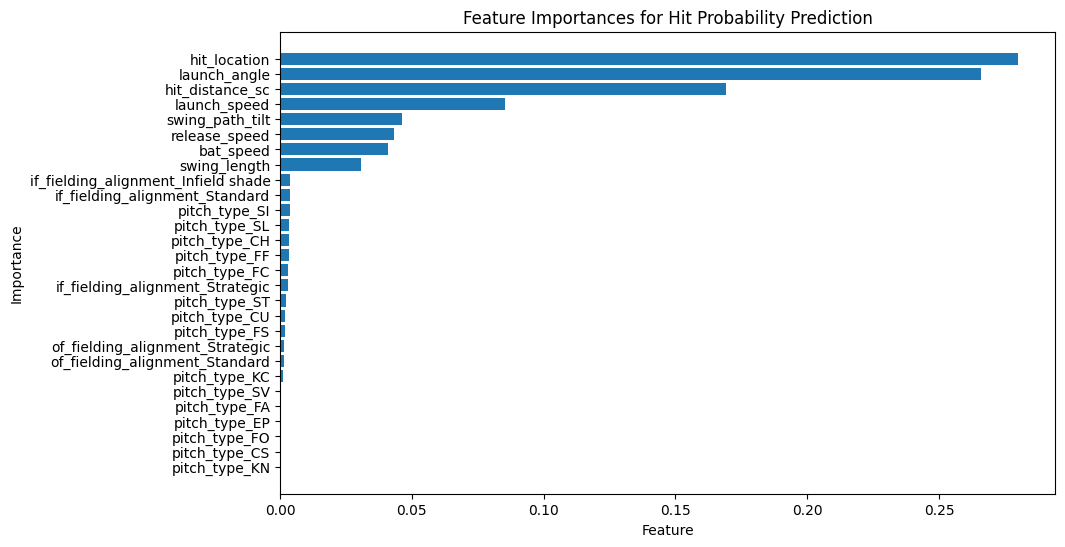

In [27]:
feature_importances_3 = pd.DataFrame({
    'feature': third_rf_features,
    'importance': third_rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feature_importances_3['feature'], feature_importances_3['importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances for Hit Probability Prediction')

## Notable Changes in Output

#### Hit location overtakes launch angle as the most important weight with an added 17,000 observations. The accuracy took a very small dip. With increased sample and slightly decreased accuracy, it is fair to say that hit location and launch angle are almost equivalent in importance based on the output of the two usable random forest models.

# Second Neural Network (Imputations)

In [28]:
# Imputations are baked into third_rf_encoded

X = third_rf_encoded.reindex(columns=third_rf_features)
y = third_rf_encoded["hit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = .2,
    random_state=42, 
    stratify = y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = np.array(X_train_scaled, dtype=np.float32)
X_test_scaled = np.array(X_test_scaled, dtype=np.float32)
y_train = np.array(y_train, dtype=np.int32)
y_test = np.array(y_test, dtype=np.int32)

print("Scaling for Second NN complete!")

Scaling for Second NN complete!


In [29]:
second_nn = keras.Sequential([
    layers.Input(shape=(28,)),
    layers.Dense(64, activation='relu', input_shape = (28,)),
    layers.Dense(2, activation='softmax')
])

second_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

second_nn.summary()

c:\Users\flana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,986 (7.76 KB)

 Trainable params: 1,986 (7.76 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
start_time = time.time()

second_nn_history = second_nn.fit(
    X_train_scaled,
    y_train,
    epochs = 20,
    batch_size = 100, 
    validation_split = .2,
    verbose = 1
)

second_nn_time = time.time() - start_time

second_nn_test_loss, second_nn_test_accuracy = second_nn.evaluate(
    X_test_scaled, y_test, verbose = 0
)

print(f'Test Accuracy: {second_nn_test_accuracy:.4f}')
print(f'Testting Loss: {second_nn_test_loss:.4f}')
print(f'First NN Training time: {second_nn_time:.2f}')

Epoch 1/20
828/828 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7947 - loss: 0.4584 - val_accuracy: 0.8438 - val_loss: 0.3999
Epoch 2/20
828/828 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8598 - loss: 0.3698 - val_accuracy: 0.8665 - val_loss: 0.3556
Epoch 3/20
828/828 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8769 - loss: 0.3366 - val_accuracy: 0.8819 - val_loss: 0.3269
Epoch 4/20
828/828 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8866 - loss: 0.3164 - val_accuracy: 0.8854 - val_loss: 0.3140
Epoch 5/20
828/828 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8912 - loss: 0.3046 - val_accuracy: 0.8883 - val_loss: 0.3035
Epoch 6/20
828/828 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8929 - loss: 0.2959 - val_accuracy: 0.8904 - val_loss: 0.2965
Epoch 7/20
828/828 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8947 - loss: 0.2900 - val_accuracy: 0.8916 - val_loss: 0.2943
Epoch 8/20
828/828 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8961 - loss: 0.2843 - val_accuracy: 0.

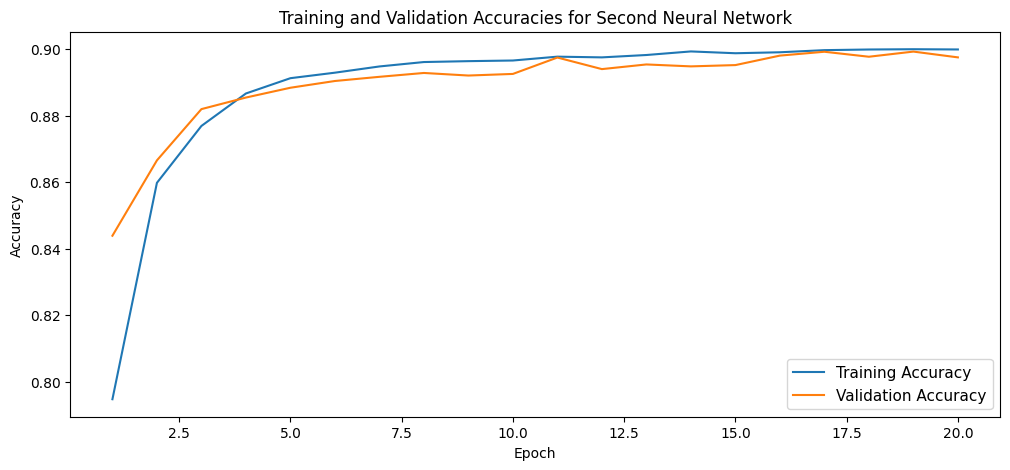

In [31]:
# Visualization for Second NN

train_accuracy = second_nn_history.history['accuracy']
val_accuracy = second_nn_history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(12,5))

plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')

plt.title("Training and Validation Accuracies for Second Neural Network")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(loc='lower right', fontsize=11)


# Comparison Table of the Four Models

In [32]:
comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Neural Network',
        'Random Forest (with imputations)',
        'Neural Network (with imputations)'
    ],
    'Test Accuracy': [
        baseline_r2,
        first_nn_test_accuracy,
        third_rf_r2,
        second_nn_test_accuracy
    ],
    'Training Time': [
        baseline_time,
        first_nn_time,
        third_rf_time,
        second_nn_time
    ]
    })

print('Model Comparisons')
print(comparison)

Model Comparisons
                               Model  Test Accuracy  Training Time
0                      Random Forest       0.667983      40.924519
1                     Neural Network       0.904077      20.751409
2   Random Forest (with imputations)       0.663749      44.140899
3  Neural Network (with imputations)       0.898891      18.682066


# Additional Analysis (Scouting Recommendation)

In [33]:
print("Top 3 Features for Non Imputation Random Forest Model (~112,000 observations):")

top_3_rf = feature_importances.sort_values(by='importance', ascending=False).head(3)
print(top_3_rf)

Top 3 Features for Non Imputation Random Forest Model (~112,000 observations):
           feature  importance
1     launch_angle    0.358120
2     hit_location    0.205910
6  hit_distance_sc    0.119128


In [34]:
print("Top 3 Features for Imputation Random Forest Model (~129,000 observations):")

top_3_irf = feature_importances_3.sort_values(by='importance', ascending=False).head(3)
print(top_3_irf)

Top 3 Features for Imputation Random Forest Model (~129,000 observations):
           feature  importance
2     hit_location    0.280046
1     launch_angle    0.265926
6  hit_distance_sc    0.169114


##### These outputs from the two random forest models paint a picture on what scouts should look for in a player. It is easy to get enthralled in someone's output numbers, but it can be very hard to scale those things to the next level because of competition level. These two models show consistent reliability in launch angle, hit location, and hit distance when it comes to hit probability and production. The weights are fitted tighter in the second random forest which makes sense because there are 17,000 more observations to go off.

##### The launch angle that leads to success here is most likely around the 25-30 degree mark. This is where many hard line drives and long fly balls (that can result in home runs) come from. Hit location comes from an ability to spray the ball to different parts of the field. While spraying singles to the opposite field does not fit the mold of modern home run hitters, it still leads to a higher hit probability in that they can use the entire field. It makes perfect sense why this and launch angle are interchangable at the 1 and 2 spots.

##### Hit distance is third in both and also the only other variable that is above 10% importance in either model. Hitting the ball further gives you a higher chance to get an extra base hit, but it does not yield the "hitting a single" value that hit location has which is why it most likely falls more flat because it essentially eliminates 1/4 of the positive outcomes.

##### In the future, this type of data analysis process could be curtailed to specific hitters and their outputs and then compared against one another. This would be good for team evaluation at a year's end, but also for prospects in the minor league system. Teams could see how much of a prospect's success is weighted on these three factors. Logically, those who lean into these more would therefore be more projectible and have a higher liklihood of moving through the ranks.

# Final Results and Summary

As of writing, these are the final outputs for the models:

Random Forest (no imputation): test accuracy of .6680 with a trainig time of 40.92 seconds

Neural Network (no imputations): test accuracy .9041 with a training time of 20.75 seconds

Random Forest (with imputations): test accuracy of .6638 with a training time of 44.14 seconds

Neural Network (with imputations): test accuracy of .8989 with a training time of 18.68 seconds

The no imputation versions of the hit probability random forest and neural network models slightly outperformed those with the imputations. The training time for the first random forest model outperfoemd the second by 4 seconds while the first neural network was 2 seconds slower with slightly better accuracy. Part of this can be attributed to the fact that the second versions had 17,000 more obsevations to deal with (for the RFs). However, with this added time, increased accuracy would be ideal, and that was not the case. In both instances, accuracy in the first models slightly outpaced their counter parts. It was marginal, but with this difference along with the disparity in training time (at least for the random forest), the no imputation models were more successful.

The two neural networks are almost identical. Both accuracies are acceptable and training times are very close. If I were to do this again, I would simply go for the one that meets my personal preference of imputation. 

The added analysis with scouting recommendations was an effort to turn these outputs from models into real ways to evaluate current players and scout future talent. There is always a need to turn these heavy data events and projects into something where someone without this background can still understand the information. Boiling it down to a simple three outputs to look for is something I am happy with because if they have further questions about it, I have all the data and justifications I need to back it up.

If I were to have a new range of data using similar features to try and predict hit probability, I would 100% use a neural network instead of a random forest. The nature of the former meshes much better than the latter with this type of data which is exhibited through the disparity in accuracy between the two models (and the fact that both iterations of the neural network hover right on 90% accuracy). Random forests do have their place in baseball, but the best performing model for this final project was the neural network with using either imputation method.